# Per-run results viewer

Loads one trained run's `.json` + `.npz` sidecar (produced by `train.ipynb` or `cascading_train.ipynb`) and re-renders every display: per-species table, paper-style metric-vs-threshold panel, ROC, float-vs-INT8 comparison, prediction-rates matrix. No retraining — everything is recomputed from the persisted predictions.

Set `COLLECTION` and `RUN_NAME` below, or pass a full `RESULTS_FILE` path.

In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from pathlib import Path
import os
import pyrootutils

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator='pyproject.toml',
    pythonpath=True,
    dotenv=True,
)

## Parameters

In [13]:
# Pick which run to view. Either set COLLECTION + RUN_NAME, or set RESULTS_FILE directly.
COLLECTION = 'task_s3_49_2_r50'
RUN_NAME = 'mel_cnn'   # base name without .json

RESULTS_FILE = ROOT / 'results' / COLLECTION / f'{RUN_NAME}.json'
NPZ_FILE = RESULTS_FILE.with_suffix('.npz')
NON_TARGET_NAME = 'non_target'
print(f'JSON: {RESULTS_FILE}  exists={RESULTS_FILE.exists()}')
print(f'NPZ : {NPZ_FILE}  exists={NPZ_FILE.exists()}')

JSON: /home/nathan/Documents/multi-chirp/results/task_s3_49_2_r50/mel_cnn.json  exists=True
NPZ : /home/nathan/Documents/multi-chirp/results/task_s3_49_2_r50/mel_cnn.npz  exists=True


## List available runs in this collection

In [14]:
results_dir = RESULTS_FILE.parent
available = sorted(p.stem for p in results_dir.glob('*.json'))
for name in available:
    marker = ' ← selected' if name == RUN_NAME else ''
    has_npz = (results_dir / f'{name}.npz').exists()
    print(f'  {name:<40s}  npz={"y" if has_npz else "n"}{marker}')

  cascading_sincnet__mel_cnn                npz=n
  cnn1d                                     npz=n
  mel_cnn                                   npz=y ← selected
  sincnet                                   npz=n
  squeezenet_mel                            npz=n


## Load the run

`load_run` returns a dict with `meta`, `float_eval`, `quant_eval`, `cmp`, `label_names`, `non_target_names`, and `npz` (raw NpzFile handle). Per-class thresholds saved in the JSON are restored so every metric matches the value originally written at training time.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from building import results_io as R
from building.models import model_eval as M

run = R.load_run(RESULTS_FILE)
float_eval = run.float_eval
quant_eval = run.quant_eval
cmp = run.cmp
meta = run.meta
label_names = run.label_names
non_target_names = run.non_target_names

print(f"run         : {meta.get('run_name')}")
print(f"model       : {meta.get('build_model')}")
print(f"epochs      : {meta.get('epochs_trained')}")
print(f"timestamp   : {meta.get('timestamp')}")
print(f"label_names : {label_names}")
if meta.get('tflite_stats'):
    s = meta['tflite_stats']
    print(f"INT8 footprint: flash={s['model_size_kb']:.1f} KB  "
          f"arena={s.get('arena_size_kb')} KB  MFLOPs={s['flops_mflops']:.3f}")
print()
M.print_summary(quant_eval)

run         : mel_cnn
model       : mel_cnn
epochs      : 36
timestamp   : 2026-05-21T12:29:07.962715+00:00
label_names : ['Emberiza_calandra', 'Hippolais_polyglotta', 'Regulus_ignicapilla', 'non_target']
INT8 footprint: flash=25.2 KB  arena=None KB  MFLOPs=0.349

=== TFLITE evaluation ===
  threshold mode    : fixed
  top-1 accuracy    : 0.8967
  subset accuracy   : 0.8678
  macro precision   : 0.8749
  macro recall      : 0.9216
  macro F1          : 0.8945
  macro F2          : 0.9098
  macro AUC         : 0.9860
  avg inference (ms): 0.409
  flash (weights)   : 25.2 KB
  est. MFLOPs       : 0.349


## Per-species metrics (quantized)

Per-class precision/recall/F1/F2/AUC at the decision threshold saved with the run. `non_target` is included in the table but excluded from the target-only macro printed below.

In [16]:
tbl = M.per_class_table(quant_eval)
tbl_targets = tbl[~tbl['class'].isin(non_target_names)]
display(tbl_targets.style.format(precision=4).set_caption('Quantized per-species'))
if quant_eval.macro_f1_targets is not None:
    print(
        f'Macro (targets only) — precision={quant_eval.macro_precision_targets:.4f}  '
        f'recall={quant_eval.macro_recall_targets:.4f}  '
        f'F1={quant_eval.macro_f1_targets:.4f}  '
        f'F2={quant_eval.macro_f2_targets:.4f}  '
        f'AUC={quant_eval.macro_auc_targets:.4f}'
    )

,class,support,threshold,precision,recall,f1,f2,auc
0,Emberiza_calandra,1200,0.5000,0.8292,0.9508,0.8859,0.9237,0.9880
1,Hippolais_polyglotta,1165,0.5000,0.8525,0.9373,0.8929,0.9190,0.9901
2,Regulus_ignicapilla,1200,0.5000,0.8514,0.9692,0.9065,0.9431,0.9953


Macro (targets only) — precision=0.8444  recall=0.9524  F1=0.8951  F2=0.9286  AUC=0.9911


## Metric-vs-threshold sweep (paper Fig. 5 style, quantized)

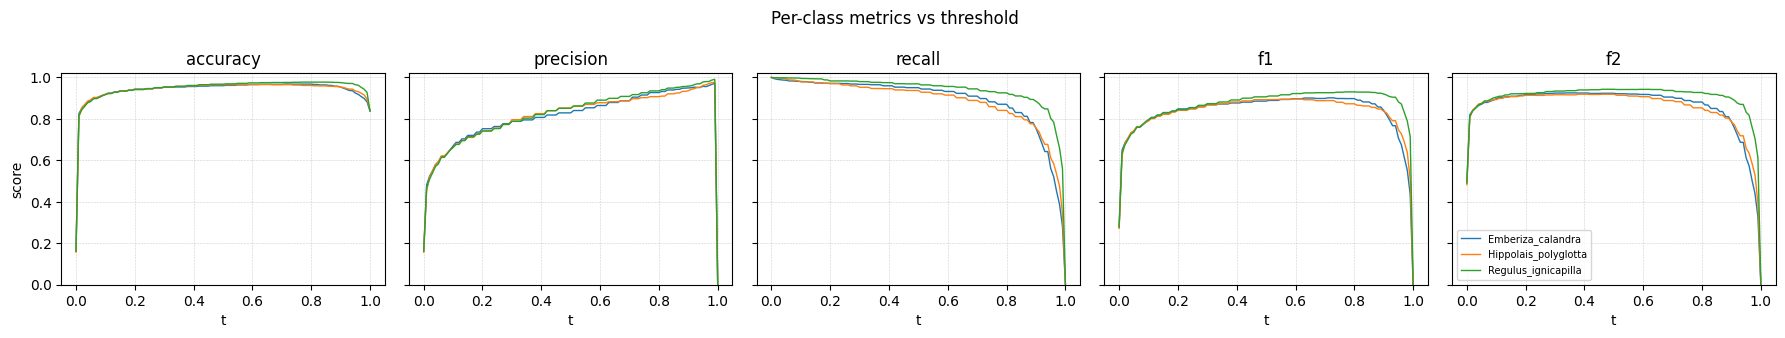

In [17]:
fig = M.plot_metric_sweep_panel(quant_eval, target_only=True)
plt.show()

## ROC per species (quantized) and AUC

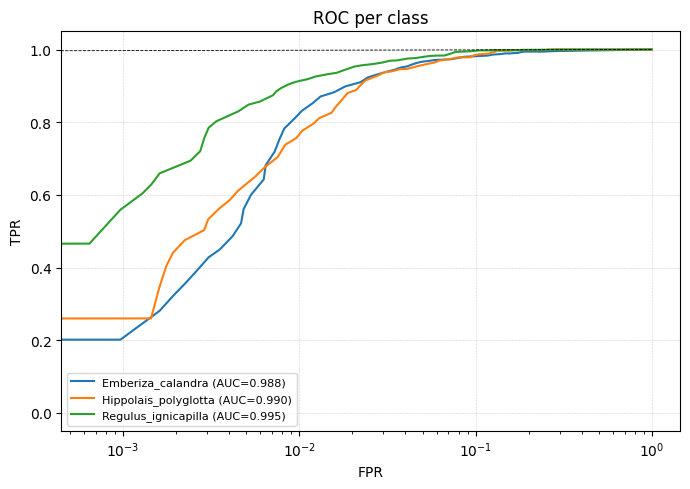

  Emberiza_calandra            AUC=0.9880
  Hippolais_polyglotta         AUC=0.9901
  Regulus_ignicapilla          AUC=0.9953


In [18]:
fig = M.plot_roc(quant_eval, target_only=True)
plt.show()
for name, mclass in quant_eval.per_class.items():
    if name in non_target_names:
        continue
    print(f'  {name:<28s} AUC={mclass.auc:.4f}' if mclass.auc is not None else f'  {name:<28s} n/a')

## Float vs INT8 comparison

,class,support,f1_float,f1_int8,df1,f2_float,f2_int8,df2,prec_float,prec_int8,rec_float,rec_int8
0,Emberiza_calandra,1200,0.892700,0.885900,-0.006900,0.922400,0.923700,0.001300,0.847300,0.829200,0.943300,0.950800
1,Hippolais_polyglotta,1165,0.895600,0.892900,-0.002700,0.914700,0.919000,0.004300,0.865500,0.852500,0.927900,0.937300
2,Regulus_ignicapilla,1200,0.910100,0.906500,-0.003600,0.942700,0.943100,0.000300,0.860400,0.851400,0.965800,0.969200
3,non_target,3847,0.897400,0.892700,-0.004700,0.860500,0.853500,-0.007000,0.966400,0.966700,0.837500,0.829200
4,MACRO,7412,0.899000,0.894500,-0.004500,0.910100,0.909800,-0.000300,0.884900,0.874900,0.918600,0.921600


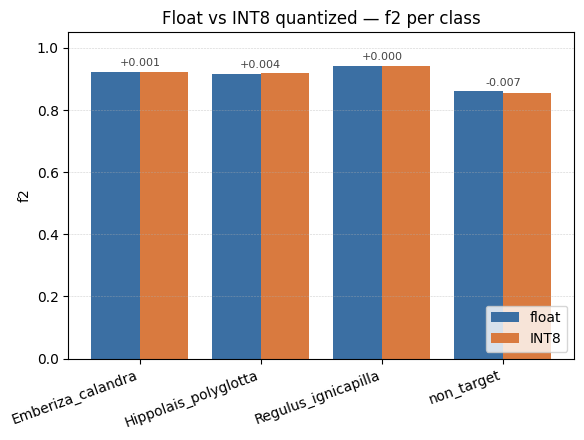

metric                    float       INT8      delta
----------------------------------------------------
top-1 accuracy           0.9025     0.8967    -0.0058
subset accuracy          0.8741     0.8678    -0.0063
macro precision          0.8849     0.8749    -0.0100
macro recall             0.9186     0.9216    +0.0030
macro F1                 0.8990     0.8945    -0.0045
macro F2                 0.9101     0.9098    -0.0003
macro AUC                0.9868     0.9860    -0.0009
avg inference ms         0.6392     0.4088    -0.2304
----------------------------------------------------
flash (weights) KB                    25.2
MFLOPs (est.)                        0.349


In [19]:
display(M.comparison_table(cmp).style.set_caption('Float vs INT8 per-class'))
fig = M.plot_quantization_drop(cmp, metric='f2')
plt.show()
M.print_comparison(cmp)

## Prediction rates by true class (quantized)

Row-stochastic matrix on the quantized predictions. Diagonal = recall; off-diagonal rows can sum past 1 because predictions are independent (multi-label sigmoid).

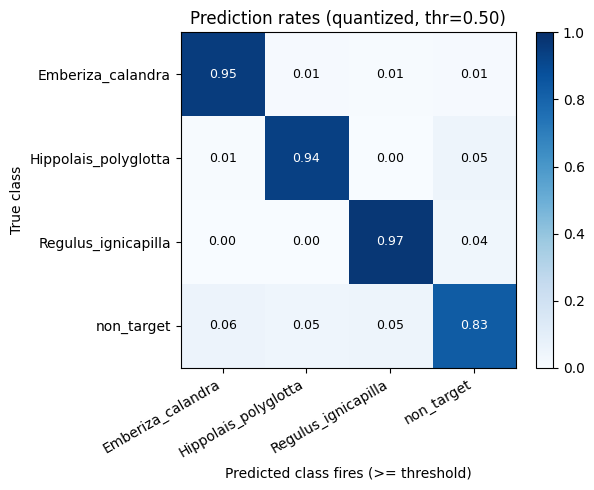

In [20]:
from building.geographic_task.results_grouped import gather_results  # noqa: F401  (handy import for cross-run work)

THRESHOLD = quant_eval.per_class[label_names[0]].threshold
y_true = quant_eval.y_true
y_score = quant_eval.y_score
y_true_bin = (y_true >= 0.5).astype(np.int32)
y_pred_bin = (y_score >= THRESHOLD).astype(np.int32)

rates = np.zeros((len(label_names), len(label_names)), dtype=np.float64)
for i in range(len(label_names)):
    mask = y_true_bin[:, i] == 1
    if mask.any():
        rates[i] = y_pred_bin[mask].mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(rates, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha='right')
ax.set_yticks(range(len(label_names)))
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted class fires (>= threshold)')
ax.set_ylabel('True class')
ax.set_title(f'Prediction rates (quantized, thr={THRESHOLD:.2f})')
for i in range(rates.shape[0]):
    for j in range(rates.shape[1]):
        ax.text(j, i, f'{rates[i, j]:.2f}',
                ha='center', va='center',
                color='white' if rates[i, j] > 0.5 else 'black', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Float vs INT8 — full delta table

Same numbers `train.ipynb` printed at training time, but recomputed from the saved predictions so you can rerun the whole notebook without touching the model.

In [21]:
deltas = meta.get('deltas', {})
print('macro_targets deltas (INT8 - float):')
for k, v in (deltas.get('macro_targets') or {}).items():
    print(f'  {k:<12s} {v:+.4f}' if v is not None else f'  {k:<12s} n/a')
print('\nper-class F2 delta:')
for name, d in (deltas.get('per_class') or {}).items():
    if name in non_target_names:
        continue
    if d.get('f2') is not None:
        print(f'  {name:<28s} {d["f2"]:+.4f}')

macro_targets deltas (INT8 - float):
  precision    -0.0134
  recall       +0.0068
  f1           -0.0044
  f2           +0.0020
  auc          -0.0006

per-class F2 delta:
  Emberiza_calandra            +0.0013
  Hippolais_polyglotta         +0.0043
  Regulus_ignicapilla          +0.0003
